<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning/blob/main/Student_Exam_Score_Prediction_Using_Custom_Loss_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [2]:
torch.manual_seed(42)

# Features:
# hours studied, attendance percentage
X = torch.tensor([
    [1.0, 50],
    [2.0, 55],
    [3.0, 60],
    [4.0, 65],
    [5.0, 70],
    [6.0, 75],
    [7.0, 80],
    [8.0, 85],
    [9.0, 90],
    [10.0, 95]
])


In [3]:
y = torch.tensor([
    [35.0],
    [40.0],
    [45.0],
    [50.0],
    [58.0],
    [65.0],
    [72.0],
    [78.0],
    [88.0],
    [95.0]
])

In [4]:
X[:, 1] = X[:, 1] / 100.0

In [5]:
class StudentScoreModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

In [6]:
class CustomWeightedMSELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, predictions, targets):
        error = predictions - targets

        # Normal MSE part
        mse = error ** 2

        # Give extra penalty when error is large
        weight = torch.where(torch.abs(error) > 10, 2.0, 1.0)

        weighted_loss = weight * mse

        return torch.mean(weighted_loss)


In [7]:
model = StudentScoreModel()
criterion = CustomWeightedMSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_history = []

for epoch in range(1000):
    predictions = model(X)
    loss = criterion(predictions, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/1000], Loss: {loss.item():.4f}")

Epoch [100/1000], Loss: 1575.3728
Epoch [200/1000], Loss: 87.7808
Epoch [300/1000], Loss: 74.9388
Epoch [400/1000], Loss: 53.9516
Epoch [500/1000], Loss: 44.3421
Epoch [600/1000], Loss: 35.0724
Epoch [700/1000], Loss: 17.5586
Epoch [800/1000], Loss: 13.8550
Epoch [900/1000], Loss: 10.5913
Epoch [1000/1000], Loss: 7.8956


In [8]:
test_student = torch.tensor([[7.5, 0.82]])

predicted_score = model(test_student)

print("\nTest Student:")
print("Hours studied: 7.5")
print("Attendance: 82%")
print(f"Predicted Exam Score: {predicted_score.item():.2f}")


Test Student:
Hours studied: 7.5
Attendance: 82%
Predicted Exam Score: 76.70


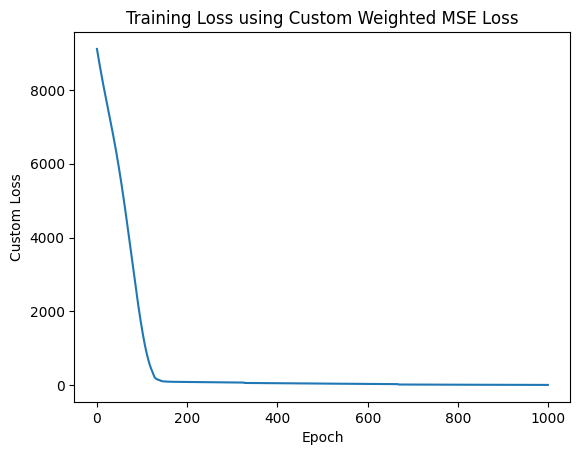

In [9]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Custom Loss")
plt.title("Training Loss using Custom Weighted MSE Loss")
plt.show()